# Task 3: 2.5D Attention U-Net for BraTS Multi-modal MRI Segmentation

This notebook keeps the original slice-level Task 3 pipeline, but each sample can use neighboring slices as 2.5D context while predicting only the center slice label.


1. Imports
This cell imports all required packages.

In [1]:
import os
import csv
import math
import random
import re
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

from task2_attention_unet_utils import (
    AttUNet,
    Attention_block,
    collect_files_for_cases,
    run_test_evaluation,
    split_cases_patient_level,
    write_case_list,
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti


/public/home/CS177/zhouzhj2023-cs177/miniforge3/envs/bmeproj2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

This is the main configuration cell.

Modify this cell if you want to change:

- data path
- batch size
- epoch number
- learning rate
- output directory
- data augmentation
- visualization frequency

In [2]:
# ============================================================
# Configuration
# ============================================================

DATA_ROOT = Path("outputs_task1/processed_slices")
if not DATA_ROOT.exists():
    fallback_data_root = Path(r"D:\Imaging\project2\processed_slices")
    if fallback_data_root.exists():
        DATA_ROOT = fallback_data_root

IMAGE_KEY = "image"
LABEL_KEY = "label"

NUM_MODALITIES = 4
SLICE_WINDOW = 3
if SLICE_WINDOW <= 0 or SLICE_WINDOW % 2 != 1:
    raise ValueError(f"SLICE_WINDOW must be a positive odd integer, got {SLICE_WINDOW}")

IN_CHANNELS = NUM_MODALITIES * SLICE_WINDOW
OUT_CHANNELS = 3

EXPERIMENT_NAME = f"unet_25d_sw{SLICE_WINDOW}"
OUTPUT_DIR = Path(f"outputs_task3_unet25d_sw{SLICE_WINDOW}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_HEIGHT = 192
IMAGE_WIDTH = 208

REGION_NAMES = ["WT", "TC", "ET"]

SEED = 42
RANDOM_SEED = SEED
TRAIN_RATIO = 0.65
VAL_RATIO = 0.20
TEST_RATIO = 0.15

BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
BASE_CHANNELS = 32
USE_ATTENTION_UNET = False

# For Windows + Jupyter, NUM_WORKERS = 0 is the safest option.
NUM_WORKERS = 0

USE_AUGMENTATION = True
USE_AMP = True

THRESHOLD = 0.5
VIS_EVERY_N_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DATA_ROOT:", DATA_ROOT.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("EXPERIMENT_NAME:", EXPERIMENT_NAME)
print("DEVICE:", DEVICE)
print("NUM_MODALITIES:", NUM_MODALITIES)
print("SLICE_WINDOW:", SLICE_WINDOW)
print("IN_CHANNELS:", IN_CHANNELS)
print("Model type:", "Attention U-Net" if USE_ATTENTION_UNET else "Baseline U-Net")


DATA_ROOT: /public/home/CS177/zhouzhj2023-cs177/MRI-segment/outputs_task1/processed_slices
OUTPUT_DIR: /public/home/CS177/zhouzhj2023-cs177/MRI-segment/outputs_task3_unet25d_sw3
EXPERIMENT_NAME: unet_25d_sw3
DEVICE: cuda
NUM_MODALITIES: 4
SLICE_WINDOW: 3
IN_CHANNELS: 12
Model type: Baseline U-Net


## 3. Reproducibility

This cell fixes random seeds for Python, NumPy and PyTorch.

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


set_seed(RANDOM_SEED)

## 4. Scan Dataset and Patient-level Train/Val/Test Split

The split is performed at patient level, not slice level, so slices from the same BraTS case do not leak across train, validation, and test sets.


In [4]:
def read_npz_value(x):
    if isinstance(x, np.ndarray):
        if x.shape == ():
            return x.item()
        return x.tolist()

    return x


SLICE_INDEX_PATTERN = re.compile(r"(?:^|[_-])slice[_-]?(\d+)$")


def get_slice_idx_from_npz_or_filename(path):
    path = Path(path)

    try:
        with np.load(path, allow_pickle=True) as data:
            if "slice_idx" in data:
                return int(read_npz_value(data["slice_idx"]))
    except Exception as exc:
        raise ValueError(f"Could not read slice_idx from npz file: {path}") from exc

    match = SLICE_INDEX_PATTERN.search(path.stem)
    if match is not None:
        return int(match.group(1))

    raise ValueError(
        f"Could not determine slice_idx for {path}. "
        "Expected a 'slice_idx' field inside the npz file or a filename ending "
        "with a pattern like '_slice_045.npz'."
    )


def build_case_to_sorted_files(slice_files):
    case_to_items = defaultdict(list)

    for path in slice_files:
        path = Path(path)
        case_id = path.parent.name
        slice_idx = get_slice_idx_from_npz_or_filename(path)
        case_to_items[case_id].append((slice_idx, path))

    case_to_files = {}
    for case_id, items in sorted(case_to_items.items()):
        seen = set()
        for slice_idx, path in items:
            if slice_idx in seen:
                raise ValueError(
                    f"Duplicate slice_idx={slice_idx} found for case_id={case_id}. "
                    f"One duplicate path is {path}."
                )
            seen.add(slice_idx)

        case_to_files[case_id] = [path for _, path in sorted(items, key=lambda x: x[0])]

    return case_to_files


def scan_dataset(data_root):
    data_root = Path(data_root)

    if not data_root.exists():
        raise FileNotFoundError(f"DATA_ROOT does not exist: {data_root}")

    all_npz_files = sorted(data_root.glob("*/*.npz"))
    if len(all_npz_files) == 0:
        raise FileNotFoundError(f"No .npz slice files found under: {data_root}")

    case_to_files = build_case_to_sorted_files(all_npz_files)
    case_ids = sorted(case_to_files.keys())

    print("Number of cases:", len(case_ids))
    print("Number of slices:", len(all_npz_files))

    counts = [len(case_to_files[c]) for c in case_ids]
    print("Slices per case:")
    print("  min   :", min(counts))
    print("  max   :", max(counts))
    print("  mean  :", float(np.mean(counts)))
    print("  median:", float(np.median(counts)))

    first_case = case_ids[0]
    first_indices = [get_slice_idx_from_npz_or_filename(p) for p in case_to_files[first_case][:5]]
    print("Example sorted case:", first_case)
    print("First sorted slice indices:", first_indices)

    return case_to_files, case_ids


case_to_files, case_ids = scan_dataset(DATA_ROOT)

train_cases, val_cases, test_cases = split_cases_patient_level(
    case_ids=case_ids,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
)

train_files = collect_files_for_cases(case_to_files, train_cases)
val_files = collect_files_for_cases(case_to_files, val_cases)
test_files = collect_files_for_cases(case_to_files, test_cases)

print()
print(
    f"Target split ratios: train={TRAIN_RATIO:.2f}, "
    f"val={VAL_RATIO:.2f}, test={TEST_RATIO:.2f}"
)
print("Random seed:", SEED)
print("Train cases:", len(train_cases))
print("Val cases  :", len(val_cases))
print("Test cases :", len(test_cases))
print("Train slices:", len(train_files))
print("Val slices  :", len(val_files))
print("Test slices :", len(test_files))
print(
    "Actual case split:",
    f"{len(train_cases) / len(case_ids):.3f}/",
    f"{len(val_cases) / len(case_ids):.3f}/",
    f"{len(test_cases) / len(case_ids):.3f}",
)

write_case_list(OUTPUT_DIR / "train_cases.txt", train_cases)
write_case_list(OUTPUT_DIR / "val_cases.txt", val_cases)
write_case_list(OUTPUT_DIR / "test_cases.txt", test_cases)


Number of cases: 595
Number of slices: 38976
Slices per case:
  min   : 25
  max   : 109
  mean  : 65.50588235294117
  median: 66.0
Example sorted case: BraTS-GLI-00000-000
First sorted slice indices: [45, 46, 47, 48, 49]

Target split ratios: train=0.65, val=0.20, test=0.15
Random seed: 42
Train cases: 387
Val cases  : 119
Test cases : 89
Train slices: 25332
Val slices  : 7882
Test slices : 5762
Actual case split: 0.650/ 0.200/ 0.150


## 5. Quick Data Sanity Check

This cell reads one `.npz` sample and checks:

- keys
- image shape
- label shape
- label values
- case ID
- slice index
- modality order
- label order

In [5]:
def inspect_npz(path):
    with np.load(path, allow_pickle=True) as data:
        print("File:", path)
        print("Keys:", list(data.files))

        image = data[IMAGE_KEY]
        label = data[LABEL_KEY]

        print("image shape:", image.shape, image.dtype)
        print("label shape:", label.shape, label.dtype)
        print("label unique:", np.unique(label))

        if "case_id" in data:
            print("case_id:", read_npz_value(data["case_id"]))

        if "slice_idx" in data:
            print("slice_idx:", read_npz_value(data["slice_idx"]))
        else:
            print("slice_idx from filename:", get_slice_idx_from_npz_or_filename(path))

        if "modality_order" in data:
            print("modality_order:", read_npz_value(data["modality_order"]))

        if "label_order" in data:
            print("label_order:", read_npz_value(data["label_order"]))


inspect_npz(train_files[0])


File: outputs_task1/processed_slices/BraTS-GLI-00000-000/BraTS-GLI-00000-000_slice_045.npz
Keys: ['image', 'label', 'case_id', 'slice_idx', 'original_shape', 'cropped_shape', 'padded_shape', 'target_h', 'target_w', 'image_padding_values', 'modality_order', 'label_order']
image shape: (4, 192, 208) float32
label shape: (3, 192, 208) uint8
label unique: [0 1]
case_id: BraTS-GLI-00000-000
slice_idx: 45
modality_order: ['T1', 'T1ce', 'T2', 'FLAIR']
label_order: ['WT', 'TC', 'ET']


## 6. Core Component: Dataset and Data Augmentation

This is one of the core cells.

The dataset returns:

```python
image: [4, 192, 208]
label: [3, 192, 208]
Data augmentation includes:

random horizontal flip
random vertical flip
random affine transformation
Gaussian noise
Important:

image uses bilinear interpolation
label uses nearest-neighbor interpolation
label remains binary after augmentation

In [6]:
def random_affine_torch(image, label, max_angle=10.0, scale_range=(0.9, 1.1), p=0.5):
    if random.random() > p:
        return image, label

    angle = random.uniform(-max_angle, max_angle) * math.pi / 180.0
    scale = random.uniform(scale_range[0], scale_range[1])

    cos_a = math.cos(angle) / scale
    sin_a = math.sin(angle) / scale

    theta = torch.tensor(
        [
            [cos_a, -sin_a, 0.0],
            [sin_a, cos_a, 0.0],
        ],
        dtype=image.dtype,
        device=image.device,
    )

    theta = theta.unsqueeze(0)

    image_4d = image.unsqueeze(0)
    label_4d = label.unsqueeze(0)

    grid = F.affine_grid(
        theta,
        image_4d.size(),
        align_corners=False,
    )

    image_aug = F.grid_sample(
        image_4d,
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=False,
    )

    label_aug = F.grid_sample(
        label_4d,
        grid,
        mode="nearest",
        padding_mode="zeros",
        align_corners=False,
    )

    image_aug = image_aug.squeeze(0)
    label_aug = label_aug.squeeze(0)

    label_aug = (label_aug > 0.5).float()

    return image_aug, label_aug


def apply_augmentation(image, label):
    if random.random() < 0.5:
        image = torch.flip(image, dims=[2])
        label = torch.flip(label, dims=[2])

    if random.random() < 0.5:
        image = torch.flip(image, dims=[1])
        label = torch.flip(label, dims=[1])

    image, label = random_affine_torch(
        image,
        label,
        max_angle=10.0,
        scale_range=(0.9, 1.1),
        p=0.5,
    )

    if random.random() < 0.3:
        noise_std = random.uniform(0.0, 0.05)
        image = image + noise_std * torch.randn_like(image)

    return image, label


class BraTSSliceDataset(Dataset):
    def __init__(self, files, augment=False, slice_window=3, case_to_files=None):
        self.files = [Path(path) for path in files]
        self.augment = augment
        self.slice_window = int(slice_window)

        if self.slice_window <= 0 or self.slice_window % 2 != 1:
            raise ValueError(
                f"slice_window must be a positive odd integer, got {self.slice_window}"
            )

        if case_to_files is None:
            self.case_to_files = build_case_to_sorted_files(self.files)
        else:
            self.case_to_files = {
                str(case_id): [Path(path) for path in paths]
                for case_id, paths in case_to_files.items()
            }

        self.file_to_case_id = {}
        self.file_to_position = {}
        self.file_to_slice_idx = {}
        for case_id, case_files in self.case_to_files.items():
            for position, path in enumerate(case_files):
                path = Path(path)
                self.file_to_case_id[path] = str(case_id)
                self.file_to_position[path] = position
                self.file_to_slice_idx[path] = get_slice_idx_from_npz_or_filename(path)

        self.path_to_dataset_index = {path: i for i, path in enumerate(self.files)}

        missing = [path for path in self.files if path not in self.file_to_position]
        if missing:
            raise ValueError(
                "Some dataset files are missing from case_to_files. "
                f"First missing file: {missing[0]}"
            )

    def __len__(self):
        return len(self.files)

    def _load_image(self, path):
        with np.load(path, allow_pickle=True) as data:
            image = data[IMAGE_KEY].astype(np.float32)

        expected_single_image_shape = (NUM_MODALITIES, IMAGE_HEIGHT, IMAGE_WIDTH)
        if image.shape != expected_single_image_shape:
            raise ValueError(
                f"Unexpected single-slice image shape {image.shape} in {path}; "
                f"expected {expected_single_image_shape}"
            )

        return image

    def _load_center_label_and_metadata(self, path):
        with np.load(path, allow_pickle=True) as data:
            label = data[LABEL_KEY].astype(np.float32)

            if "case_id" in data:
                case_id = read_npz_value(data["case_id"])
            else:
                case_id = path.parent.name

            if "slice_idx" in data:
                slice_idx = int(read_npz_value(data["slice_idx"]))
            else:
                slice_idx = get_slice_idx_from_npz_or_filename(path)

        expected_label_shape = (OUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH)
        if label.shape != expected_label_shape:
            raise ValueError(
                f"Unexpected label shape {label.shape} in {path}; "
                f"expected {expected_label_shape}"
            )

        return label, str(case_id), int(slice_idx)

    def _context_paths_for_center(self, path):
        case_id = self.file_to_case_id[path]
        case_files = self.case_to_files[case_id]
        center_position = self.file_to_position[path]
        radius = self.slice_window // 2

        context_paths = []
        for offset in range(-radius, radius + 1):
            neighbor_position = min(
                max(center_position + offset, 0),
                len(case_files) - 1,
            )
            context_paths.append(case_files[neighbor_position])

        return context_paths

    def __getitem__(self, idx):
        path = self.files[idx]

        label, case_id, slice_idx = self._load_center_label_and_metadata(path)
        context_paths = self._context_paths_for_center(path)
        context_images = [self._load_image(context_path) for context_path in context_paths]
        image = np.concatenate(context_images, axis=0)

        expected_image_shape = (
            NUM_MODALITIES * self.slice_window,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        )
        if image.shape != expected_image_shape:
            raise ValueError(
                f"Unexpected 2.5D image shape {image.shape} for center path {path}; "
                f"expected {expected_image_shape}"
            )

        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).float()

        if self.augment:
            image, label = apply_augmentation(image, label)

        sample = {
            "image": image,
            "label": label,
            "case_id": str(case_id),
            "slice_idx": int(slice_idx),
            "path": str(path),
            "context_slice_indices": [
                int(self.file_to_slice_idx[context_path]) for context_path in context_paths
            ],
            "context_paths": [str(context_path) for context_path in context_paths],
        }

        return sample


train_dataset = BraTSSliceDataset(
    train_files,
    augment=USE_AUGMENTATION,
    slice_window=SLICE_WINDOW,
    case_to_files=case_to_files,
)
val_dataset = BraTSSliceDataset(
    val_files,
    augment=False,
    slice_window=SLICE_WINDOW,
    case_to_files=case_to_files,
)
test_dataset = BraTSSliceDataset(
    test_files,
    augment=False,
    slice_window=SLICE_WINDOW,
    case_to_files=case_to_files,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

batch = next(iter(train_loader))

print("image batch shape:", batch["image"].shape, batch["image"].dtype)
print("label batch shape:", batch["label"].shape, batch["label"].dtype)
print("Example case_id:", batch["case_id"][0])
print("Example slice_idx:", batch["slice_idx"][0])
print("Example path:", batch["path"][0])
print("Dataset sizes:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Loader batches:", len(train_loader), len(val_loader), len(test_loader))

example_sample = train_dataset[0]
print("Example sample image shape:", tuple(example_sample["image"].shape))
print("Example sample label shape:", tuple(example_sample["label"].shape))
print("Example context slice indices:", example_sample["context_slice_indices"])

check_2d_dataset = BraTSSliceDataset(
    [train_files[0]],
    augment=False,
    slice_window=1,
    case_to_files=case_to_files,
)
check_2d_sample = check_2d_dataset[0]
print("slice_window=1 image shape:", tuple(check_2d_sample["image"].shape))

if SLICE_WINDOW > 1:
    boundary_case_id = next(case for case in train_cases if len(case_to_files[case]) >= 2)
    first_path = case_to_files[boundary_case_id][0]
    last_path = case_to_files[boundary_case_id][-1]

    first_sample = train_dataset[train_dataset.path_to_dataset_index[first_path]]
    last_sample = train_dataset[train_dataset.path_to_dataset_index[last_path]]

    print("Boundary case:", boundary_case_id)
    print("First-slice context indices:", first_sample["context_slice_indices"])
    print("Last-slice context indices:", last_sample["context_slice_indices"])


image batch shape: torch.Size([8, 12, 192, 208]) torch.float32
label batch shape: torch.Size([8, 3, 192, 208]) torch.float32
Example case_id: BraTS-GLI-00049-000
Example slice_idx: tensor(71)
Example path: outputs_task1/processed_slices/BraTS-GLI-00049-000/BraTS-GLI-00049-000_slice_071.npz
Dataset sizes: 25332 7882 5762
Loader batches: 3167 986 721
Example sample image shape: (12, 192, 208)
Example sample label shape: (3, 192, 208)
Example context slice indices: [45, 45, 46]
slice_window=1 image shape: (4, 192, 208)
Boundary case: BraTS-GLI-00000-000
First-slice context indices: [45, 45, 46]
Last-slice context indices: [90, 91, 91]


## 7. Visualize Training Sample

This cell visualizes one image slice and its WT / TC / ET masks.

If modality order is `[T1, T1ce, T2, FLAIR]`, then channel 3 is FLAIR.

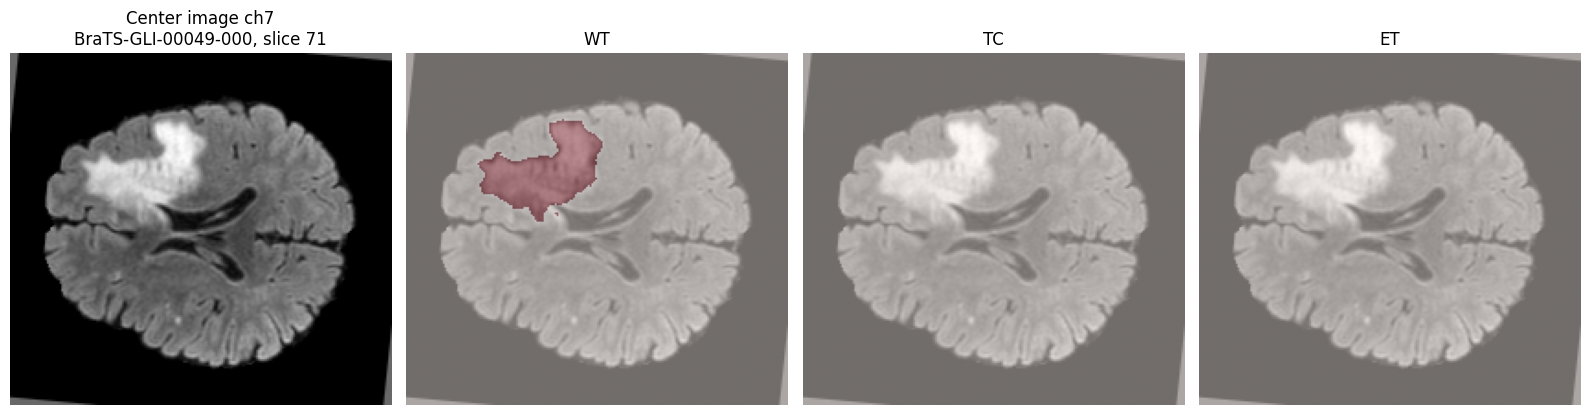

In [7]:
def get_center_display_channel(
    num_modalities=NUM_MODALITIES,
    slice_window=SLICE_WINDOW,
    modality_index=3,
):
    if num_modalities <= 0:
        raise ValueError(f"num_modalities must be positive, got {num_modalities}")

    if slice_window <= 0 or slice_window % 2 != 1:
        raise ValueError(f"slice_window must be a positive odd integer, got {slice_window}")

    if modality_index < 0 or modality_index >= num_modalities:
        raise ValueError(
            f"modality_index must be in [0, {num_modalities - 1}], got {modality_index}"
        )

    return (slice_window // 2) * num_modalities + modality_index


def show_sample_from_batch(batch, index=0, modality_index=3):
    image = batch["image"][index].numpy()
    label = batch["label"][index].numpy()

    case_id = batch["case_id"][index]
    slice_idx = batch["slice_idx"][index]

    if torch.is_tensor(slice_idx):
        slice_idx = slice_idx.item()

    display_channel = get_center_display_channel(
        num_modalities=NUM_MODALITIES,
        slice_window=SLICE_WINDOW,
        modality_index=modality_index,
    )

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(image[display_channel], cmap="gray")
    axes[0].set_title(
        f"Center image ch{display_channel}\n{case_id}, slice {slice_idx}"
    )
    axes[0].axis("off")

    for i, name in enumerate(REGION_NAMES):
        axes[i + 1].imshow(image[display_channel], cmap="gray")
        axes[i + 1].imshow(label[i], cmap="Reds", alpha=0.45)
        axes[i + 1].set_title(name)
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()


show_sample_from_batch(batch, index=0, modality_index=3)


## 8. Core Component: U-Net Network Architecture

This is the main model definition cell.

Input:

```python
[B, 4, 192, 208]
Output logits:

[B, 3, 192, 208]
The final layer does not use sigmoid.

Sigmoid is applied inside the loss function and during validation.

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=True,
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2,
            ],
        )

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)


class UNet2D(nn.Module):
    def __init__(self, in_channels=4, out_channels=3, base_channels=32):
        super().__init__()

        self.in_conv = DoubleConv(in_channels, base_channels)

        self.down1 = Down(base_channels, base_channels * 2)
        self.down2 = Down(base_channels * 2, base_channels * 4)
        self.down3 = Down(base_channels * 4, base_channels * 8)
        self.down4 = Down(base_channels * 8, base_channels * 16)

        self.up1 = Up(base_channels * 16 + base_channels * 8, base_channels * 8)
        self.up2 = Up(base_channels * 8 + base_channels * 4, base_channels * 4)
        self.up3 = Up(base_channels * 4 + base_channels * 2, base_channels * 2)
        self.up4 = Up(base_channels * 2 + base_channels, base_channels)

        self.out_conv = nn.Conv2d(
            base_channels,
            out_channels,
            kernel_size=1,
        )

    def forward(self, x):
        x1 = self.in_conv(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.out_conv(x)

        return logits


model_class = AttUNet if USE_ATTENTION_UNET else UNet2D
model = model_class(
    in_channels=IN_CHANNELS,
    out_channels=OUT_CHANNELS,
    base_channels=BASE_CHANNELS,
).to(DEVICE)

# Shape check uses the configured 2.5D tensor layout: [B, IN_CHANNELS, H, W].
x_test = torch.randn(
    1,
    IN_CHANNELS,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
).to(DEVICE)

with torch.no_grad():
    y_test = model(x_test)

print("Model class:", model.__class__.__name__)
print("Input shape:", x_test.shape)
print("Output shape:", y_test.shape)

expected_shape = (1, OUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH)
assert tuple(y_test.shape) == expected_shape, (
    f"Expected output shape {expected_shape}, got {tuple(y_test.shape)}"
)

num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable:,}")


Model class: UNet2D
Input shape: torch.Size([1, 12, 192, 208])
Output shape: torch.Size([1, 3, 192, 208])
Total parameters: 7,852,259
Trainable parameters: 7,852,259


## 9. Core Component: Dice Loss and Hybrid Loss

This cell defines the loss function.

The final loss is:

```python
Loss = DiceLoss + BCEWithLogitsLoss
This is suitable for class-imbalanced multi-label medical image segmentation.

The model outputs logits, not probabilities.

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()

        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        dims = (0, 2, 3)

        intersection = torch.sum(probs * targets, dim=dims)
        denominator = torch.sum(probs, dim=dims) + torch.sum(targets, dim=dims)

        dice = (2.0 * intersection + self.smooth) / (
            denominator + self.smooth
        )

        loss = 1.0 - dice

        return loss.mean()


class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=1.0, bce_weight=1.0):
        super().__init__()

        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        dice = self.dice_loss(logits, targets)
        bce = self.bce_loss(logits, targets)

        total = self.dice_weight * dice + self.bce_weight * bce

        loss_parts = {
            "dice_loss": float(dice.detach().cpu()),
            "bce_loss": float(bce.detach().cpu()),
        }

        return total, loss_parts


criterion = DiceBCELoss(
    dice_weight=1.0,
    bce_weight=1.0,
).to(DEVICE)

print(criterion)

DiceBCELoss(
  (dice_loss): DiceLoss()
  (bce_loss): BCEWithLogitsLoss()
)


## 10. Core Component: Dice Metric

This cell computes validation Dice for:

- WT
- TC
- ET
- Mean Dice

Prediction is obtained by:

```python
prob = sigmoid(logits)
pred = prob > threshold

In [10]:
class DiceAccumulator:
    def __init__(self, num_channels=3, threshold=0.5, smooth=1e-5):
        self.num_channels = num_channels
        self.threshold = threshold
        self.smooth = smooth

        self.intersection = torch.zeros(num_channels, dtype=torch.float64)
        self.pred_sum = torch.zeros(num_channels, dtype=torch.float64)
        self.target_sum = torch.zeros(num_channels, dtype=torch.float64)

    @torch.no_grad()
    def update(self, logits, targets):
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).float()
        targets = targets.float()

        dims = (0, 2, 3)

        intersection = torch.sum(preds * targets, dim=dims)
        pred_sum = torch.sum(preds, dim=dims)
        target_sum = torch.sum(targets, dim=dims)

        self.intersection += intersection.detach().cpu().double()
        self.pred_sum += pred_sum.detach().cpu().double()
        self.target_sum += target_sum.detach().cpu().double()

    def compute(self):
        dice = (2.0 * self.intersection + self.smooth) / (
            self.pred_sum + self.target_sum + self.smooth
        )

        return dice.numpy()

## 11. Optimizer and Scheduler

This cell defines:

- AdamW optimizer
- ReduceLROnPlateau scheduler
- AMP GradScaler

In [11]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

scaler = torch.cuda.amp.GradScaler(
    enabled=(USE_AMP and DEVICE.type == "cuda")
)


def get_current_lr(optimizer):
    return optimizer.param_groups[0]["lr"]


print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


/tmp/ipykernel_36743/673542364.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


## 12. Core Component: Training and Validation Loops

This cell defines:

- `train_one_epoch`
- `validate_one_epoch`

This is the main training logic.

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()

    running_loss = 0.0
    running_dice_loss = 0.0
    running_bce_loss = 0.0
    num_samples = 0

    pbar = tqdm(loader, desc="Train", leave=False)

    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        batch_size = images.size(0)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None and scaler.is_enabled():
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss, loss_parts = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:
            logits = model(images)
            loss, loss_parts = criterion(logits, labels)

            loss.backward()
            optimizer.step()

        running_loss += loss.item() * batch_size
        running_dice_loss += loss_parts["dice_loss"] * batch_size
        running_bce_loss += loss_parts["bce_loss"] * batch_size
        num_samples += batch_size

        pbar.set_postfix(
            {
                "loss": running_loss / max(num_samples, 1),
                "lr": get_current_lr(optimizer),
            }
        )

    metrics = {
        "loss": running_loss / num_samples,
        "dice_loss": running_dice_loss / num_samples,
        "bce_loss": running_bce_loss / num_samples,
    }

    return metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    running_dice_loss = 0.0
    running_bce_loss = 0.0
    num_samples = 0

    dice_acc = DiceAccumulator(
        num_channels=OUT_CHANNELS,
        threshold=threshold,
    )

    pbar = tqdm(loader, desc="Val", leave=False)

    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        batch_size = images.size(0)

        logits = model(images)
        loss, loss_parts = criterion(logits, labels)

        running_loss += loss.item() * batch_size
        running_dice_loss += loss_parts["dice_loss"] * batch_size
        running_bce_loss += loss_parts["bce_loss"] * batch_size
        num_samples += batch_size

        dice_acc.update(logits, labels)

        pbar.set_postfix(
            {
                "loss": running_loss / max(num_samples, 1),
            }
        )

    dice_values = dice_acc.compute()

    metrics = {
        "loss": running_loss / num_samples,
        "dice_loss": running_dice_loss / num_samples,
        "bce_loss": running_bce_loss / num_samples,
        "dice_wt": float(dice_values[0]),
        "dice_tc": float(dice_values[1]),
        "dice_et": float(dice_values[2]),
        "mean_dice": float(np.mean(dice_values)),
    }

    return metrics

## 13. Prediction Visualization Function

This cell defines the visualization function.

The output image contains:

- input MRI channel
- ground truth WT / TC / ET
- predicted WT / TC / ET

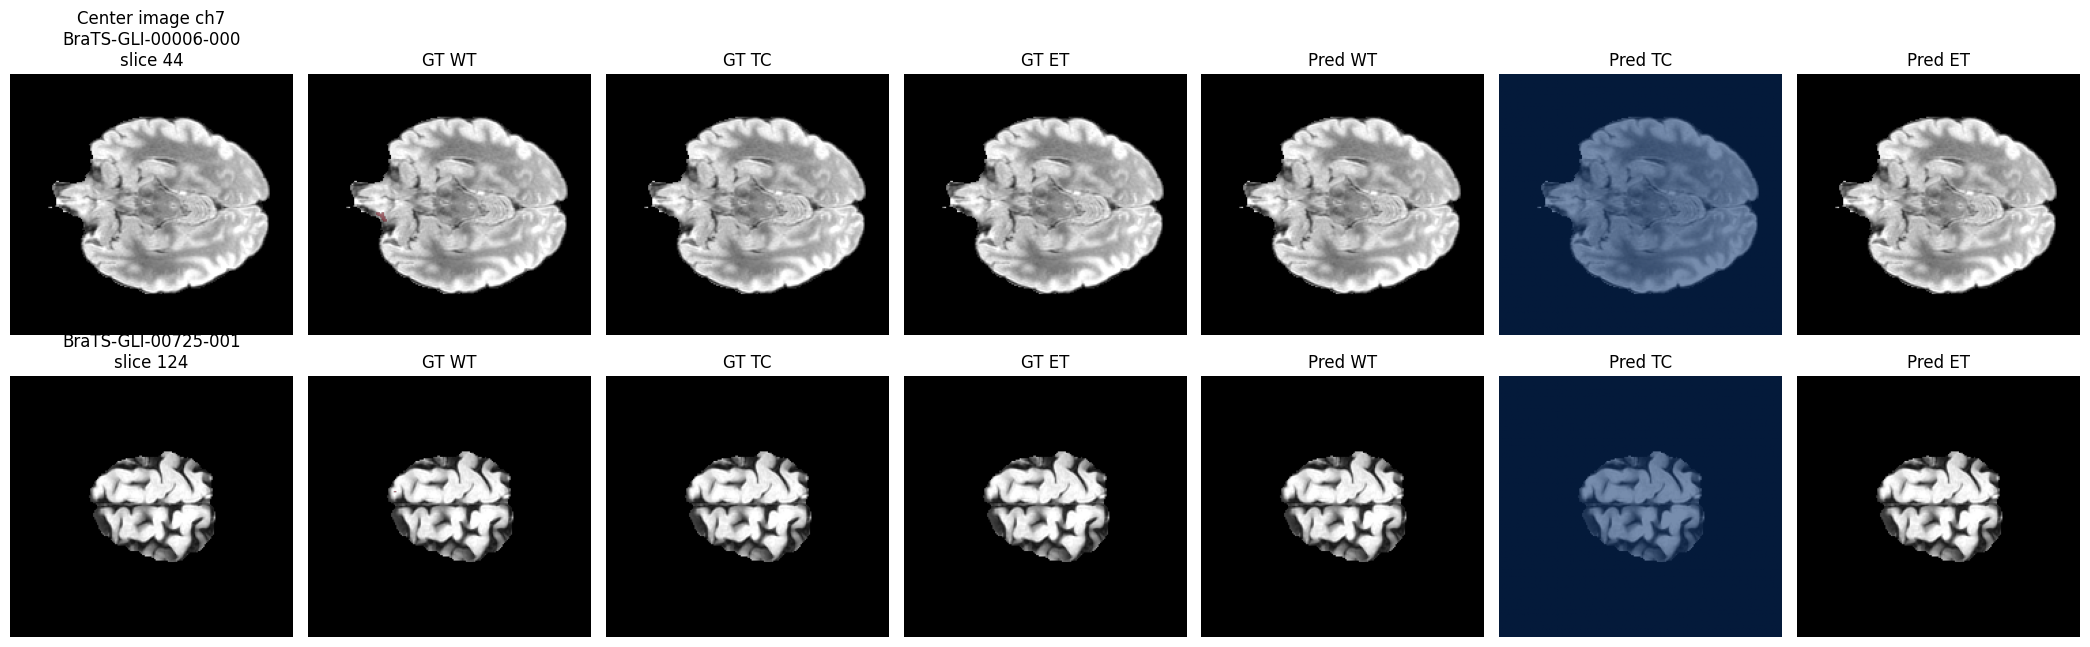

In [13]:
def normalize_mri_for_display(img, eps=1e-6):
    """Normalize MRI slice for visualization while keeping background black."""
    img = img.astype(np.float32)

    foreground_mask = np.abs(img) > eps
    out = np.zeros_like(img, dtype=np.float32)

    if foreground_mask.sum() == 0:
        return out

    foreground_values = img[foreground_mask]
    vmin = np.percentile(foreground_values, 1)
    vmax = np.percentile(foreground_values, 99)

    if vmax <= vmin:
        return out

    out[foreground_mask] = (img[foreground_mask] - vmin) / (vmax - vmin)
    return np.clip(out, 0.0, 1.0)


@torch.no_grad()
def visualize_predictions(
    model,
    dataset,
    device,
    save_path,
    num_samples=3,
    modality_index=3,
    threshold=0.5,
    num_modalities=NUM_MODALITIES,
    slice_window=SLICE_WINDOW,
):
    model.eval()

    display_channel = get_center_display_channel(
        num_modalities=num_modalities,
        slice_window=slice_window,
        modality_index=modality_index,
    )
    indices = np.linspace(0, len(dataset) - 1, num_samples).astype(int)

    fig, axes = plt.subplots(
        num_samples,
        7,
        figsize=(21, 3.2 * num_samples),
    )

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        sample = dataset[idx]

        image_tensor = sample["image"].unsqueeze(0).to(device)
        label = sample["label"].numpy()

        logits = model(image_tensor)
        prob = torch.sigmoid(logits)[0].detach().cpu().numpy()
        pred = (prob > threshold).astype(np.float32)

        image_np = sample["image"].numpy()
        bg = image_np[display_channel]

        bg_display = normalize_mri_for_display(bg)

        case_id = sample["case_id"]
        slice_idx = sample["slice_idx"]

        axes[row, 0].imshow(
            bg_display,
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, 0].set_title(
            f"Center image ch{display_channel}\n{case_id}\nslice {slice_idx}"
        )
        axes[row, 0].axis("off")

        for c, name in enumerate(REGION_NAMES):
            axes[row, 1 + c].imshow(
                bg_display,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            gt_mask = np.ma.masked_where(label[c] <= 0.5, label[c])

            axes[row, 1 + c].imshow(
                gt_mask,
                cmap="Reds",
                alpha=0.55,
                vmin=0,
                vmax=1,
            )

            axes[row, 1 + c].set_title(f"GT {name}")
            axes[row, 1 + c].axis("off")

        for c, name in enumerate(REGION_NAMES):
            axes[row, 4 + c].imshow(
                bg_display,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            pred_mask = np.ma.masked_where(pred[c] <= 0.5, pred[c])

            axes[row, 4 + c].imshow(
                pred_mask,
                cmap="Blues",
                alpha=0.55,
                vmin=0,
                vmax=1,
            )

            axes[row, 4 + c].set_title(f"Pred {name}")
            axes[row, 4 + c].axis("off")

    plt.tight_layout()

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


visualize_predictions(
    model=model,
    dataset=val_dataset,
    device=DEVICE,
    save_path=OUTPUT_DIR / "prediction_before_training_black_bg_overlay.png",
    num_samples=2,
    modality_index=3,
    threshold=THRESHOLD,
    num_modalities=NUM_MODALITIES,
    slice_window=SLICE_WINDOW,
)


## 14. Main Training Loop

The 2.5D Attention U-Net run writes all artifacts into `outputs_task3_unet25d_sw{SLICE_WINDOW}/`.

It saves:

```text
outputs_task3_unet25d_sw3/
- best_attention_unet25d_sw3.pth
- last_attention_unet25d_sw3.pth
- training_history.csv
- prediction_before_training_black_bg_overlay.png
- prediction_epoch_xxx.png
```

The best model is selected by validation mean Dice.

Early stopping patience is 20 epochs without validation mean Dice improvement.


Resuming training from checkpoint:
outputs_task3_unet25d_sw3/last_attention_unet25d_sw3.pth
Checkpoint epoch: 63
Resume from epoch: 64
Current best mean Dice: 0.9262
Early stopping patience: 20
Epochs without improvement: 14
Epoch 64/80


Train:   0%|                                                                                                                                                                                                           | 0/3167 [00:00<?, ?it/s]/tmp/ipykernel_36743/331614103.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Train:   2%|████▏                                                                                                                                                                     | 77/3167 [00:17<10:42,  4.81it/s, loss=0.058, lr=3.13e-5]

LR: 3.125000e-05 | Train Loss: 0.0564 | Val Loss: 0.2992 | Dice WT: 0.9456 | Dice TC: 0.9171 | Dice ET: 0.9135 | Mean Dice: 0.9254
Early stopping counter: 15/20
Epoch 65/80


LR: 3.125000e-05 | Train Loss: 0.0561 | Val Loss: 0.3005 | Dice WT: 0.9454 | Dice TC: 0.9174 | Dice ET: 0.9130 | Mean Dice: 0.9252
Early stopping counter: 16/20


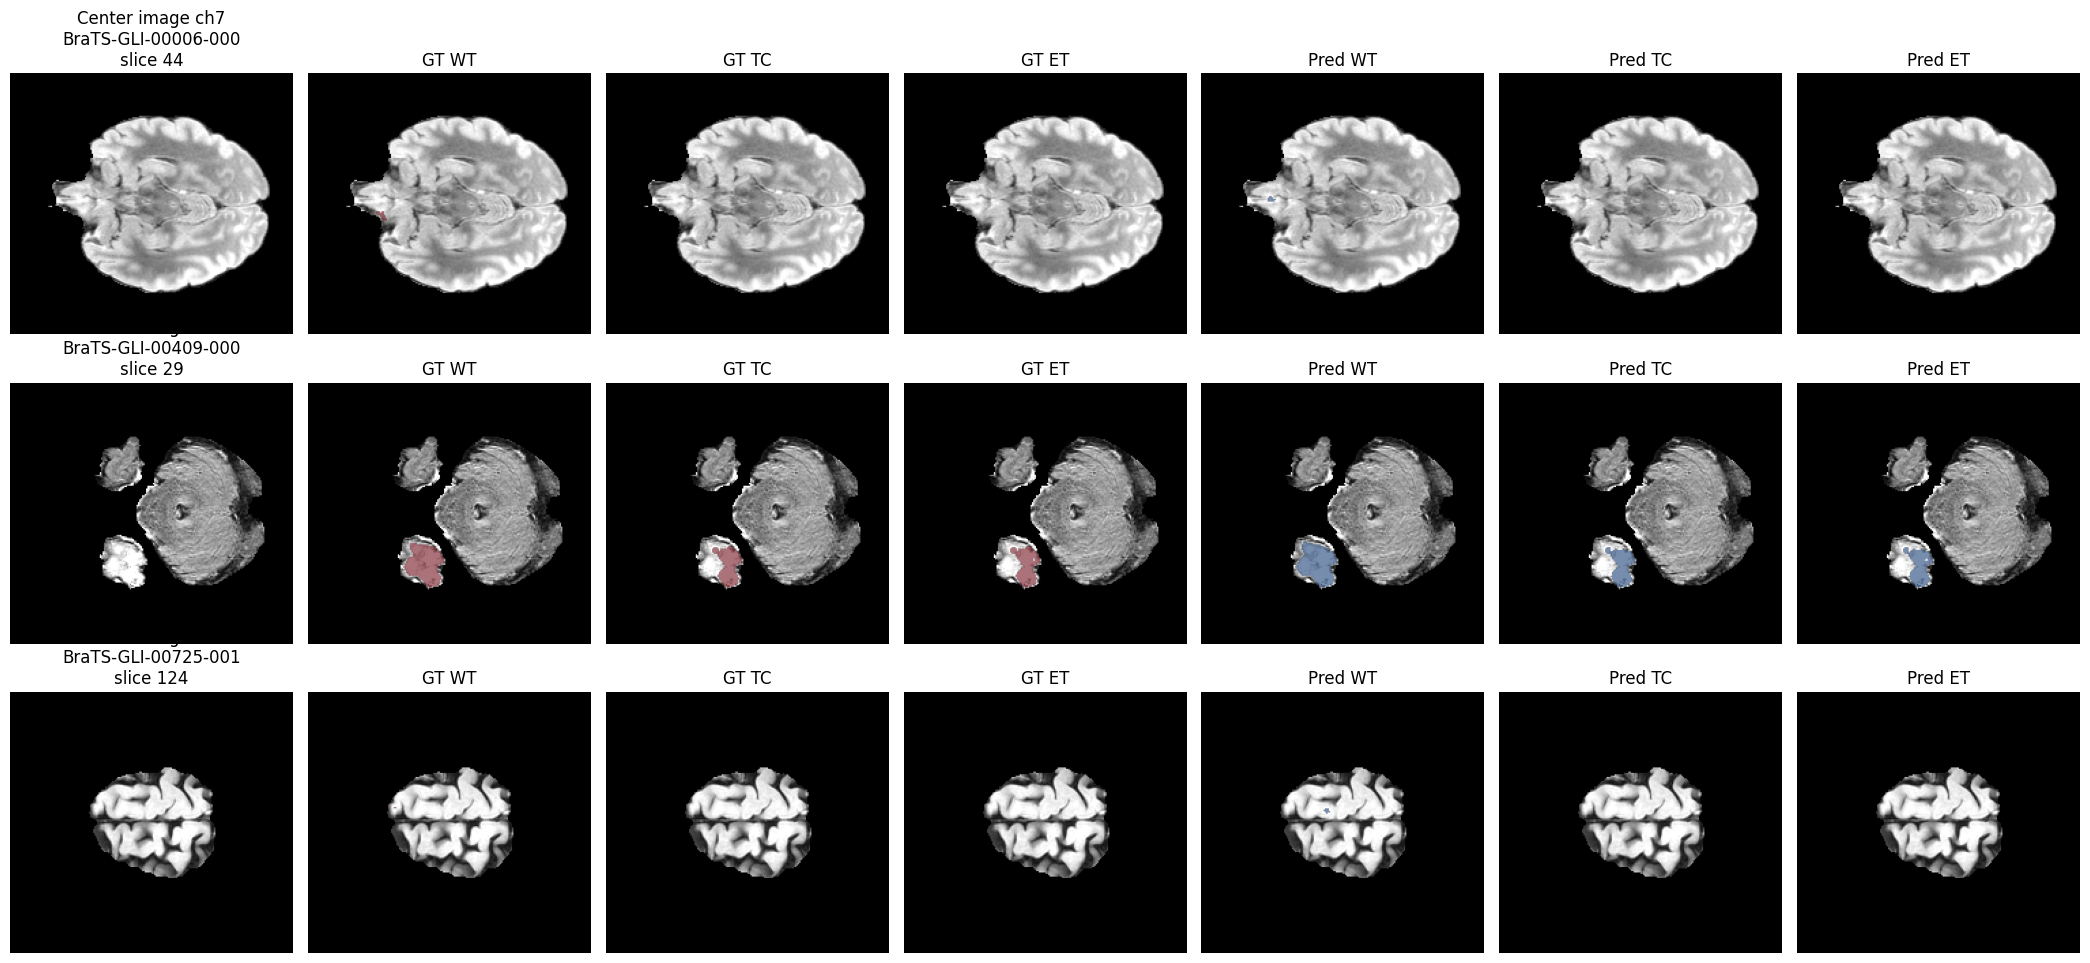

Epoch 66/80


LR: 3.125000e-05 | Train Loss: 0.0563 | Val Loss: 0.2991 | Dice WT: 0.9457 | Dice TC: 0.9179 | Dice ET: 0.9140 | Mean Dice: 0.9259
Early stopping counter: 17/20
Epoch 67/80


LR: 1.562500e-05 | Train Loss: 0.0561 | Val Loss: 0.3006 | Dice WT: 0.9458 | Dice TC: 0.9165 | Dice ET: 0.9123 | Mean Dice: 0.9249
Early stopping counter: 18/20
Epoch 68/80


LR: 1.562500e-05 | Train Loss: 0.0558 | Val Loss: 0.3011 | Dice WT: 0.9455 | Dice TC: 0.9165 | Dice ET: 0.9124 | Mean Dice: 0.9248
Early stopping counter: 19/20
Epoch 69/80


LR: 1.562500e-05 | Train Loss: 0.0561 | Val Loss: 0.2997 | Dice WT: 0.9458 | Dice TC: 0.9178 | Dice ET: 0.9133 | Mean Dice: 0.9256
Early stopping counter: 20/20
Early stopping triggered after 69 epochs. Best Mean Dice = 0.9262

Training finished.
Best Mean Dice: 0.9262
Elapsed time: 86.05 minutes
Best model: outputs_task3_unet25d_sw3/best_attention_unet25d_sw3.pth
Last model: outputs_task3_unet25d_sw3/last_attention_unet25d_sw3.pth
Training history: outputs_task3_unet25d_sw3/training_history.csv


In [14]:
log_path = OUTPUT_DIR / "training_history.csv"
best_model_path = OUTPUT_DIR / f"best_attention_unet25d_sw{SLICE_WINDOW}.pth"
last_model_path = OUTPUT_DIR / f"last_attention_unet25d_sw{SLICE_WINDOW}.pth"

# If True, load the matching last 2.5D checkpoint and continue training.
RESUME_TRAINING = True

# This means total target epochs, not additional epochs.
# Example:
#   If you already trained 50 epochs and set TOTAL_EPOCHS = 80,
#   it will continue from epoch 51 to epoch 80.
TOTAL_EPOCHS = 80

RESUME_CHECKPOINT_PATH = last_model_path

history_fieldnames = [
    "epoch",
    "learning_rate",
    "lr",
    "train_loss",
    "train_dice_loss",
    "train_bce_loss",
    "val_loss",
    "val_dice_loss",
    "val_bce_loss",
    "val_dice",
    "dice_wt",
    "dice_tc",
    "dice_et",
    "mean_dice",
]

start_epoch = 1
best_mean_dice = -1.0
epochs_without_improvement = 0
history = []


def initialize_history_file(path, fieldnames):
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()


def append_history_row(path, fieldnames, row):
    with open(path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writerow(row)


def get_best_mean_dice_from_log(log_path):
    if not Path(log_path).exists():
        return -1.0

    best_value = -1.0

    with open(log_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            for key in ("mean_dice", "val_dice"):
                if key in row:
                    try:
                        value = float(row[key])
                        best_value = max(best_value, value)
                    except ValueError:
                        pass

    return best_value


if RESUME_TRAINING and RESUME_CHECKPOINT_PATH.exists():
    print("Resuming training from checkpoint:")
    print(RESUME_CHECKPOINT_PATH)

    checkpoint = torch.load(
        RESUME_CHECKPOINT_PATH,
        map_location=DEVICE,
    )

    model.load_state_dict(checkpoint["model_state_dict"])

    if "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    checkpoint_epoch = int(checkpoint["epoch"])
    start_epoch = checkpoint_epoch + 1

    best_mean_dice = float(checkpoint.get("best_mean_dice", -1.0))
    epochs_without_improvement = int(checkpoint.get("epochs_without_improvement", 0))

    # In case best_mean_dice in last_attention_unet.pth is slightly stale,
    # recover the best value from training_history.csv.
    best_from_log = get_best_mean_dice_from_log(log_path)
    best_mean_dice = max(best_mean_dice, best_from_log)

    if not log_path.exists():
        initialize_history_file(log_path, history_fieldnames)

    print(f"Checkpoint epoch: {checkpoint_epoch}")
    print(f"Resume from epoch: {start_epoch}")
    print(f"Current best mean Dice: {best_mean_dice:.4f}")
    print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
    print(f"Epochs without improvement: {epochs_without_improvement}")

else:
    print("Starting training from scratch.")

    start_epoch = 1
    best_mean_dice = -1.0
    epochs_without_improvement = 0
    initialize_history_file(log_path, history_fieldnames)


if start_epoch > TOTAL_EPOCHS:
    print(
        f"Checkpoint epoch is already {start_epoch - 1}, "
        f"which is >= TOTAL_EPOCHS={TOTAL_EPOCHS}."
    )
    print("No further training will be performed.")

else:
    start_time = time.time()

    for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
        print("=" * 80)
        print(f"Epoch {epoch}/{TOTAL_EPOCHS}")
        print("=" * 80)

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=DEVICE,
            scaler=scaler,
        )

        val_metrics = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE,
            threshold=THRESHOLD,
        )

        scheduler.step(val_metrics["mean_dice"])

        lr = get_current_lr(optimizer)

        row = {
            "epoch": epoch,
            "learning_rate": lr,
            "lr": lr,
            "train_loss": train_metrics["loss"],
            "train_dice_loss": train_metrics["dice_loss"],
            "train_bce_loss": train_metrics["bce_loss"],
            "val_loss": val_metrics["loss"],
            "val_dice_loss": val_metrics["dice_loss"],
            "val_bce_loss": val_metrics["bce_loss"],
            "val_dice": val_metrics["mean_dice"],
            "dice_wt": val_metrics["dice_wt"],
            "dice_tc": val_metrics["dice_tc"],
            "dice_et": val_metrics["dice_et"],
            "mean_dice": val_metrics["mean_dice"],
        }

        history.append(row)

        print(
            f"LR: {lr:.6e} | "
            f"Train Loss: {row['train_loss']:.4f} | "
            f"Val Loss: {row['val_loss']:.4f} | "
            f"Dice WT: {row['dice_wt']:.4f} | "
            f"Dice TC: {row['dice_tc']:.4f} | "
            f"Dice ET: {row['dice_et']:.4f} | "
            f"Mean Dice: {row['mean_dice']:.4f}"
        )

        append_history_row(log_path, history_fieldnames, row)

        is_best = row["mean_dice"] > best_mean_dice
        if is_best:
            best_mean_dice = row["mean_dice"]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Early stopping counter: "
            f"{epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
        )

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_mean_dice": best_mean_dice,
            "epochs_without_improvement": epochs_without_improvement,
            "model_class": model.__class__.__name__,
            "config": {
                "num_modalities": NUM_MODALITIES,
                "slice_window": SLICE_WINDOW,
                "in_channels": IN_CHANNELS,
                "out_channels": OUT_CHANNELS,
                "base_channels": BASE_CHANNELS,
                "image_height": IMAGE_HEIGHT,
                "image_width": IMAGE_WIDTH,
                "threshold": THRESHOLD,
                "use_attention_unet": USE_ATTENTION_UNET,
                "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            },
        }

        # Save latest checkpoint.
        torch.save(checkpoint, last_model_path)

        # Save best checkpoint selected by validation mean Dice.
        if is_best:
            torch.save(checkpoint, best_model_path)
            print(f"Saved new best model. Mean Dice = {best_mean_dice:.4f}")

        if epoch % VIS_EVERY_N_EPOCHS == 0 or epoch == TOTAL_EPOCHS:
            visualize_predictions(
                model=model,
                dataset=val_dataset,
                device=DEVICE,
                save_path=OUTPUT_DIR / f"prediction_epoch_{epoch:03d}.png",
                num_samples=3,
                modality_index=3,
                num_modalities=NUM_MODALITIES,
                slice_window=SLICE_WINDOW,
                threshold=THRESHOLD,
            )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping triggered after {epoch} epochs. "
                f"Best Mean Dice = {best_mean_dice:.4f}"
            )
            break

    elapsed = time.time() - start_time

    print()
    print("Training finished.")
    print(f"Best Mean Dice: {best_mean_dice:.4f}")
    print(f"Elapsed time: {elapsed / 60:.2f} minutes")
    print("Best model:", best_model_path)
    print("Last model:", last_model_path)
    print("Training history:", log_path)


## 15. Plot Training Curves

This cell plots:

- training loss
- validation loss
- Dice WT
- Dice TC
- Dice ET
- mean Dice

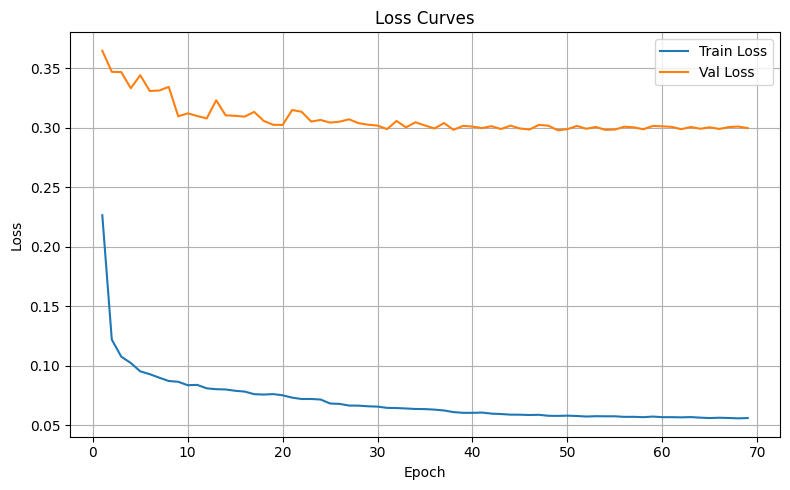

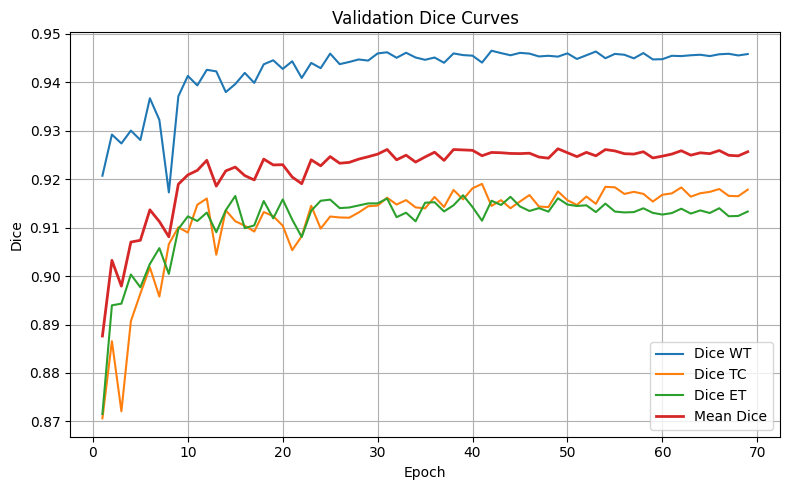

Best epoch log:
{'epoch': 49.0, 'learning_rate': 0.000125, 'lr': 0.000125, 'train_loss': 0.05787144122874965, 'train_dice_loss': 0.05099423027694574, 'train_bce_loss': 0.0068772109301862856, 'val_loss': 0.2979457105461019, 'val_dice_loss': 0.2840610639780828, 'val_bce_loss': 0.013884646597647304, 'val_dice': 0.9262492179627017, 'dice_wt': 0.9452520060568123, 'dice_tc': 0.9174542116651488, 'dice_et': 0.916041436166144, 'mean_dice': 0.9262492179627017}


In [15]:
def load_logs(log_path):
    rows = []

    with open(log_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            rows.append({k: float(v) for k, v in row.items()})

    return rows


logs = load_logs(log_path)

epochs = [r["epoch"] for r in logs]

train_loss = [r["train_loss"] for r in logs]
val_loss = [r["val_loss"] for r in logs]

dice_wt = [r["dice_wt"] for r in logs]
dice_tc = [r["dice_tc"] for r in logs]
dice_et = [r["dice_et"] for r in logs]
mean_dice = [r["mean_dice"] for r in logs]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, dice_wt, label="Dice WT")
plt.plot(epochs, dice_tc, label="Dice TC")
plt.plot(epochs, dice_et, label="Dice ET")
plt.plot(epochs, mean_dice, label="Mean Dice", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Validation Dice Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dice_curve.png", dpi=150)
plt.show()

best_idx = int(np.argmax(mean_dice))

print("Best epoch log:")
print(logs[best_idx])

## 16. Load Best Model and Visualize Final Validation Predictions

Use this cell after training.

It loads the best 2.5D Attention U-Net checkpoint for the configured `SLICE_WINDOW` and generates final validation prediction maps.


Loaded best model from epoch: 49
Best Mean Dice: 0.9262492179627017


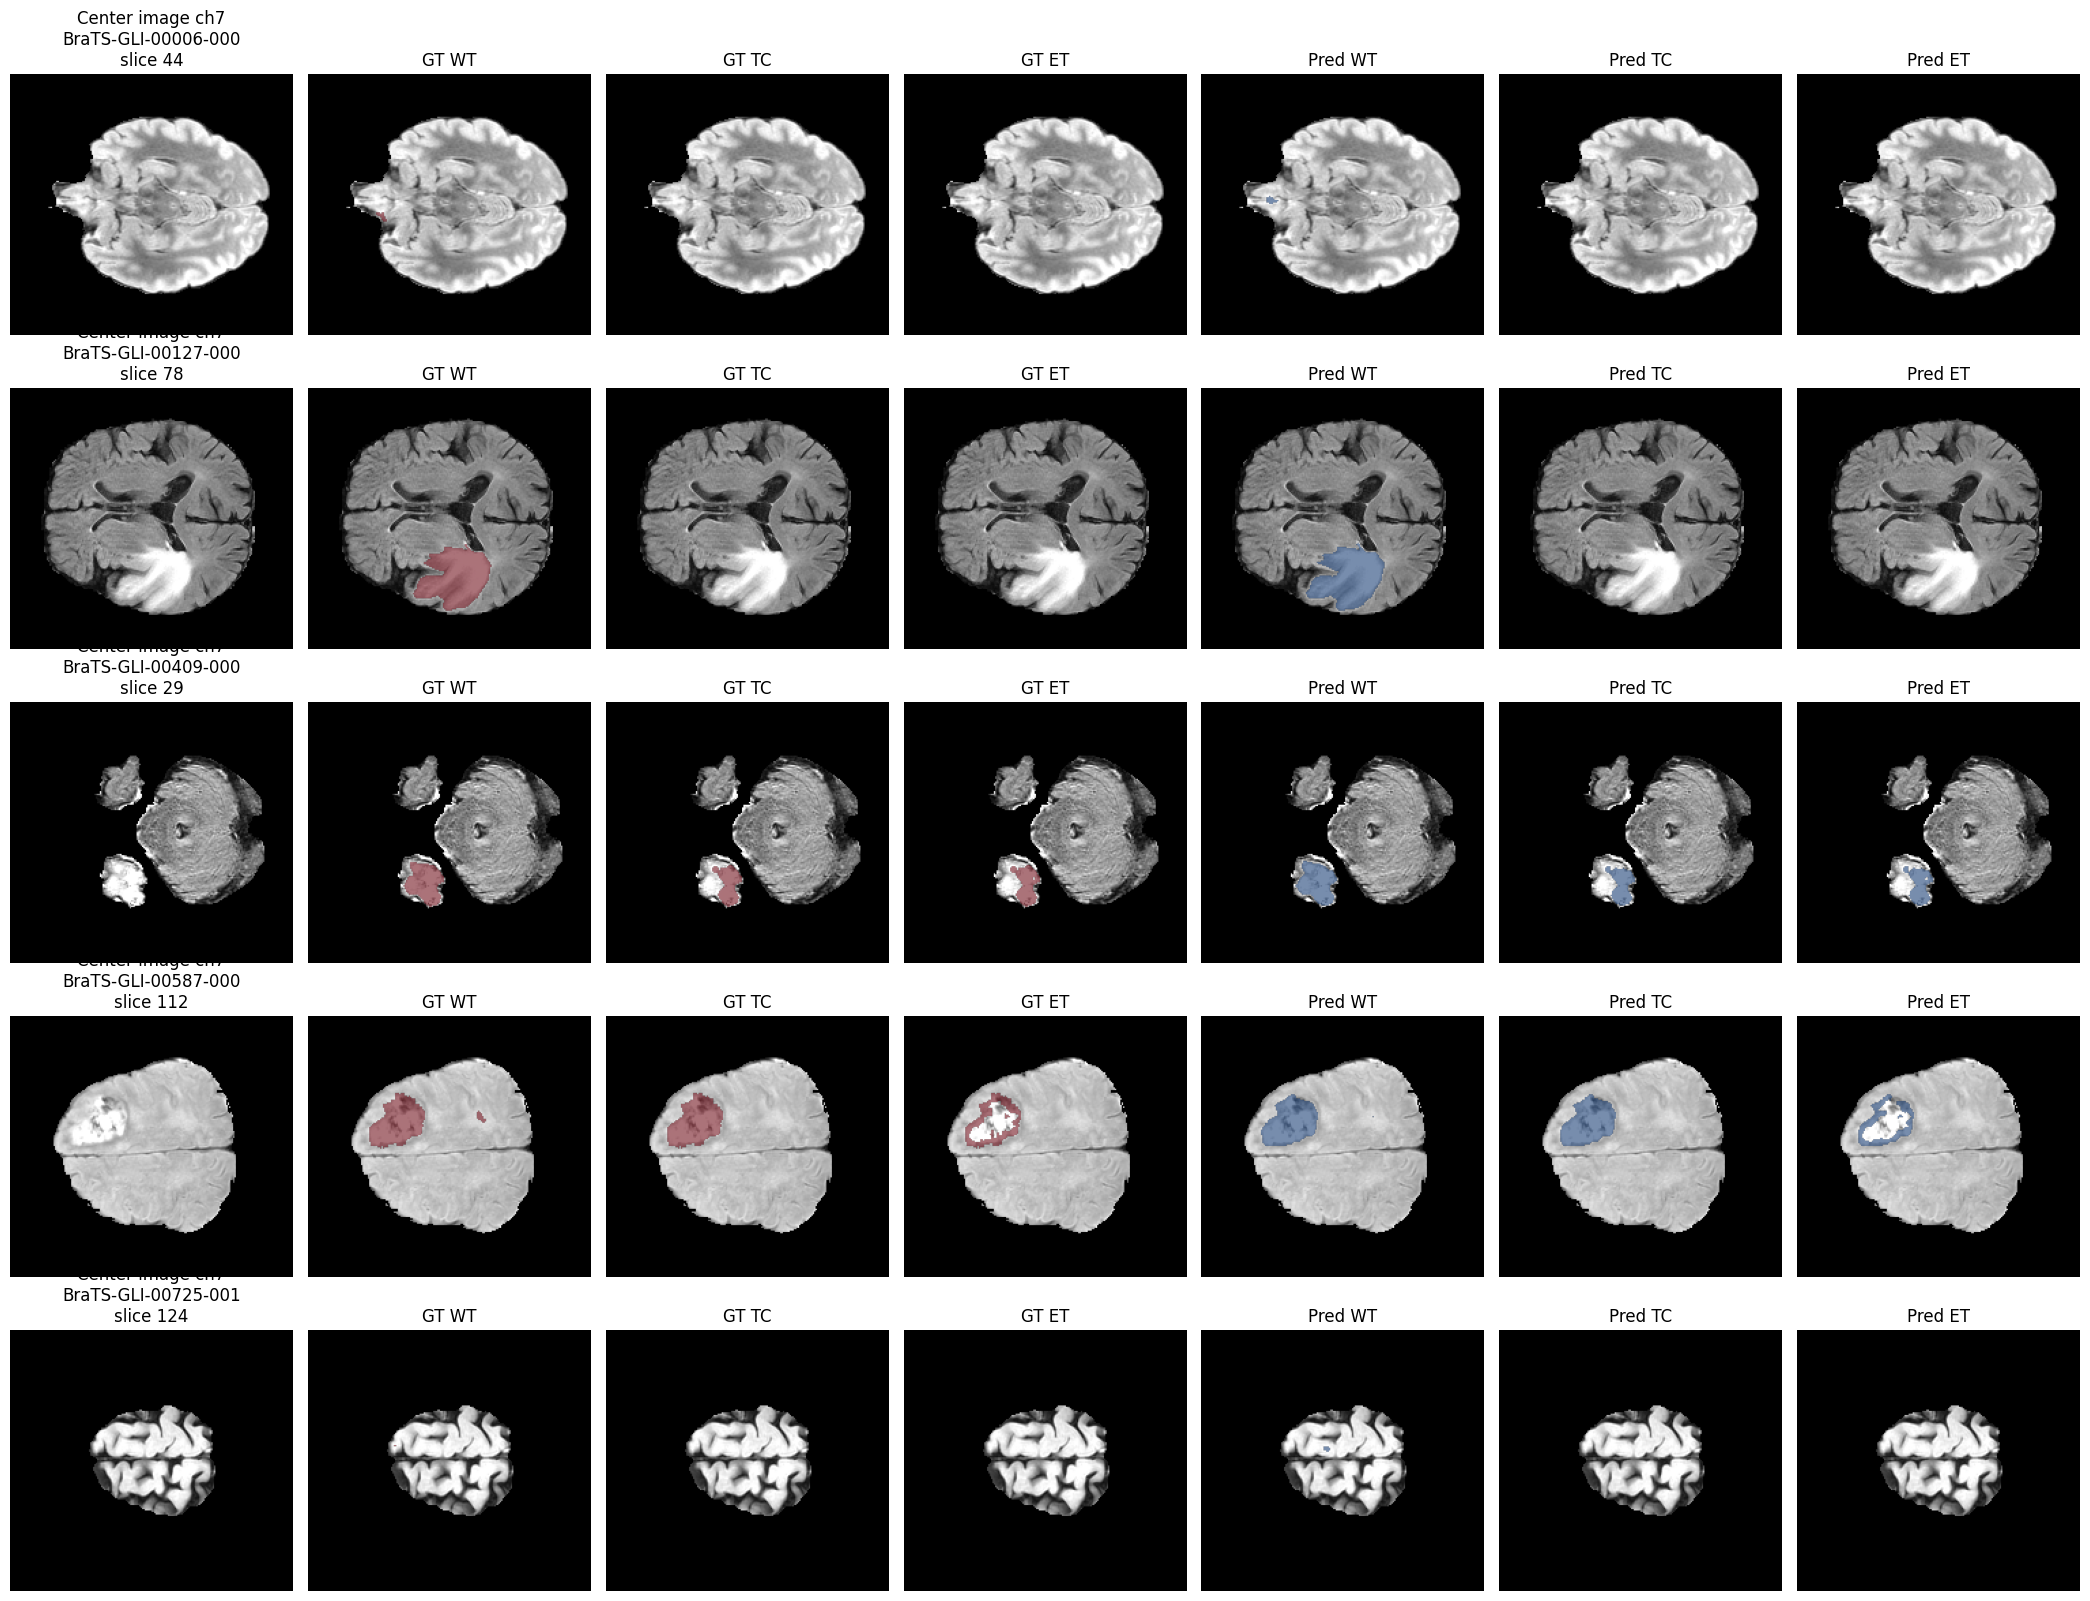

In [16]:
if "best_model_path" not in globals():
    best_model_path = OUTPUT_DIR / f"best_attention_unet25d_sw{SLICE_WINDOW}.pth"

best_checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE,
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Loaded best model from epoch:", best_checkpoint["epoch"])
print("Best Mean Dice:", best_checkpoint["best_mean_dice"])

visualize_predictions(
    model=model,
    dataset=val_dataset,
    device=DEVICE,
    save_path=OUTPUT_DIR / "prediction_best_model_validation.png",
    num_samples=5,
    modality_index=3,
    num_modalities=NUM_MODALITIES,
    slice_window=SLICE_WINDOW,
    threshold=THRESHOLD,
)


Loaded best model for test evaluation: outputs_task3_unet25d_sw3/best_attention_unet25d_sw3.pth
Checkpoint epoch: 49
Best validation mean Dice: 0.9262492179627017


Test Dice: 0.8992 ± 0.1555
Test HD95: 3.0935 ± 5.1095
Per-case/per-slice metrics: outputs_task3_unet25d_sw3/test_metrics_per_case.csv
Summary metrics: outputs_task3_unet25d_sw3/test_metrics_summary.csv
Worst 5 CSV: outputs_task3_unet25d_sw3/worst5_cases.csv
Worst 5 markdown: outputs_task3_unet25d_sw3/worst5_error_analysis.md
Worst 5 visualizations: outputs_task3_unet25d_sw3/worst5_visualizations
Test metrics across cases
  Mean Dice  : 0.8962  ±0.0590  [0.7000, 0.9781]
  Mean HD95  : 3.07  ±1.95  [0.64, 9.20]

Per-region Dice:
  WT: 0.8602 ± 0.1004
  TC: 0.9234 ± 0.0508
  ET: 0.9050 ± 0.0583

Case-level metrics saved to: outputs_task3_unet25d_sw3/test_metrics_per_case_aggregated.csv


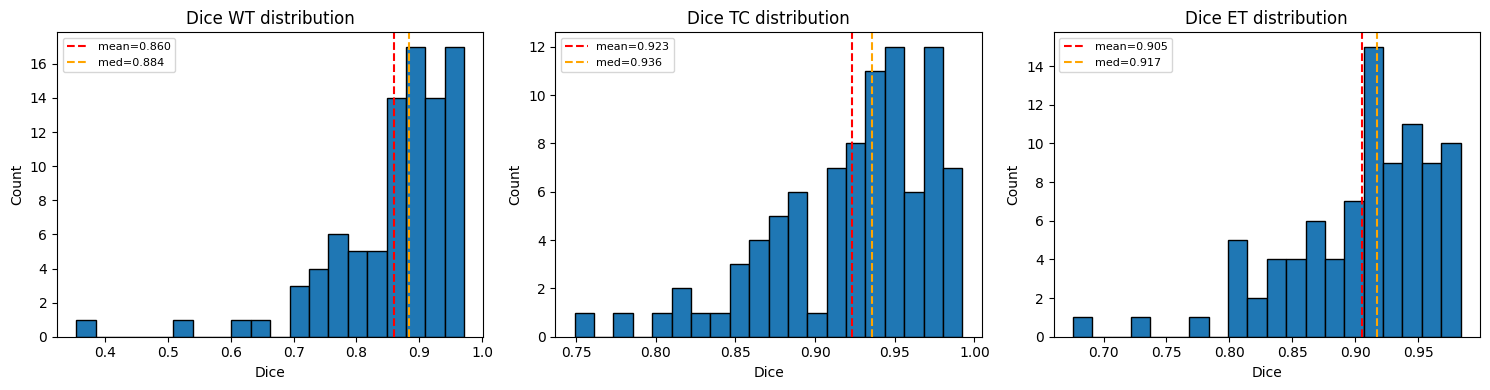

In [17]:
# ============================================================
# Test evaluation: Dice + HD95 + case-level summary
# ============================================================

# Jupyter keeps imported functions cached. Reload the helper so fixes in
# task2_attention_unet_utils.py are used without restarting the kernel.
import csv
import importlib
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import task2_attention_unet_utils as task2_utils

task2_utils = importlib.reload(task2_utils)

if "best_model_path" not in globals():
    best_model_path = OUTPUT_DIR / f"best_attention_unet25d_sw{SLICE_WINDOW}.pth"

metric_rows, summary_rows = task2_utils.run_test_evaluation(
    model=model,
    test_loader=test_loader,
    test_dataset=test_dataset,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    best_model_path=best_model_path,
    region_names=REGION_NAMES,
    threshold=THRESHOLD,
    save_worst5=True,
    num_modalities=NUM_MODALITIES,
    slice_window=SLICE_WINDOW,
    modality_index=3,
)


def finite_values(values):
    values = np.asarray(values, dtype=np.float64)
    return values[~np.isnan(values)]


def summarize_values(values):
    values = finite_values(values)
    if values.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    return (
        float(np.mean(values)),
        float(np.std(values)),
        float(np.min(values)),
        float(np.max(values)),
    )


def aggregate_metrics_by_case(rows):
    case_to_rows = defaultdict(list)
    for row in rows:
        case_to_rows[row["case_id"]].append(row)

    metric_keys = ["dice", "hd95"] + [f"dice_{name.lower()}" for name in REGION_NAMES]
    metric_keys += [f"hd95_{name.lower()}" for name in REGION_NAMES]

    case_results = []
    for case_id, case_rows in sorted(case_to_rows.items()):
        case_result = {
            "case_id": case_id,
            "num_slices": len(case_rows),
            "slice_start": min(int(r["slice_idx"]) for r in case_rows),
            "slice_end": max(int(r["slice_idx"]) for r in case_rows),
        }

        for key in metric_keys:
            vals = [float(r[key]) for r in case_rows if key in r and r[key] != ""]
            vals = finite_values(vals)
            case_result[key] = float(np.mean(vals)) if vals.size > 0 else np.nan

        case_results.append(case_result)

    return case_results


def save_case_results_csv(case_results, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = []
    for row in case_results:
        for key in row.keys():
            if key not in fieldnames:
                fieldnames.append(key)

    with open(save_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(case_results)


case_results = aggregate_metrics_by_case(metric_rows)
case_results_path = OUTPUT_DIR / "test_metrics_per_case_aggregated.csv"
save_case_results_csv(case_results, case_results_path)

mean_dice, std_dice, min_dice, max_dice = summarize_values([r["dice"] for r in case_results])
mean_hd95, std_hd95, min_hd95, max_hd95 = summarize_values([r["hd95"] for r in case_results])

print("Test metrics across cases")
print(f"  Mean Dice  : {mean_dice:.4f}  ±{std_dice:.4f}  [{min_dice:.4f}, {max_dice:.4f}]")
print(f"  Mean HD95  : {mean_hd95:.2f}  ±{std_hd95:.2f}  [{min_hd95:.2f}, {max_hd95:.2f}]")
print()
print("Per-region Dice:")
for name in REGION_NAMES:
    key = f"dice_{name.lower()}"
    region_mean, region_std, _, _ = summarize_values([r[key] for r in case_results])
    print(f"  {name}: {region_mean:.4f} ± {region_std:.4f}")

print()
print("Case-level metrics saved to:", case_results_path)

# Distribution of Dice across all test cases.
fig, axes = plt.subplots(1, len(REGION_NAMES), figsize=(5 * len(REGION_NAMES), 4))
if len(REGION_NAMES) == 1:
    axes = [axes]

for i, name in enumerate(REGION_NAMES):
    key = f"dice_{name.lower()}"
    vals = finite_values([r[key] for r in case_results])

    axes[i].hist(vals, bins=20, edgecolor="black")
    axes[i].axvline(
        np.mean(vals),
        color="red",
        linestyle="--",
        label=f"mean={np.mean(vals):.3f}",
    )
    axes[i].axvline(
        np.median(vals),
        color="orange",
        linestyle="--",
        label=f"med={np.median(vals):.3f}",
    )
    axes[i].set_title(f"Dice {name} distribution")
    axes[i].set_xlabel("Dice")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dice_distribution.png", dpi=150)
plt.show()


## 17. Notes for Report

- This notebook implements 2.5D slice-level Attention U-Net input by concatenating neighboring slice images on the channel axis.
- `SLICE_WINDOW = 1` is the original 2D setting with `[4, H, W]` inputs.
- `SLICE_WINDOW = 3` uses `[z-1, z, z+1]`, giving `[12, H, W]` inputs while labels remain `[3, H, W]` from the center slice.
- Patient-level train/val/test splitting remains unchanged and is performed before expanding cases to slice files.
- Worst-5 visualizations display the configured modality from the center slice, not from a neighboring context slice.
